M1-M4 are the assumed models. M1-M12 are observation data-generating processes.

DeepSet, 2*num_dim, 10 observation,DeepSet,epochs=256, inference network: depth=8, widths=(256,256,256), "norm": "layer", larger training budget for M3
log marginal likelihood estimation: mean-log

In [1]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
sd.quiet_bayesflow_progress()

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 10
num_datasets = 50
num_samples = 1000
n_ref = 2000

project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_dir = project_dir / "results" / "ood_40d_10n_altlogml"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},

    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},

    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
#pd.DataFrame(source_specs).T

In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [4]:
# Load original datasets with fixed posterior samples.
# This keeps the same observed data and the same NPE posterior samples as ood_40d_10n.
original_dataset_dir = project_dir / "results" / "ood_40d_10n" / "datasets"
datasets = {
    source: load_pickle(original_dataset_dir / f"{source}_logml_pmp.pkl")
    for source in sd.SOURCE_MODELS
}

In [5]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_40d_10n.keras"
filepath_m2 = network_dir / "m2_s_40d_10n.keras"
filepath_m3 = network_dir / "m3_s_40d_10n.keras"
filepath_m4 = network_dir / "m4_s_40d_10n.keras"
filepath_direct = network_dir / "direct_s_20d_10n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [6]:
# Compute logmls and PMPs
calculation_m1 = Calculation(approximator=approximator_m1,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m1",)
calculation_m2 = Calculation(approximator=approximator_m2,mu_prior_mean=3.0,mu_prior_std=1.0,
    num_dims=num_dims,num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m2",)
calculation_m3 = Calculation(approximator=approximator_m3,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=3.0,num_samples=num_samples,assumed_model="m3",)
calculation_m4 = Calculation(approximator=approximator_m4,mu_prior_mean=0.1,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m4",)

calculations = {"m1": calculation_m1, "m2": calculation_m2, "m3": calculation_m3, "m4": calculation_m4}

In [7]:
# Recompute logmls with mean-log estimation, using the already saved posterior samples.
# Do not call sd.compute_logml_and_posteriors here, because that would resample NPE posteriors.
from benchmark.examples.gaussian.npe.estimation import MarginalLikelihoodEstimator
from benchmark.examples.gaussian.direct import calculator as BF


def recompute_logml_from_existing_samples(datasets, calculations, method="mean_log"):
    for assumed, calc in calculations.items():
        for source in sd.SOURCE_MODELS:
            for item in datasets[source]:
                estimator = MarginalLikelihoodEstimator(
                    approximator=calc.approximator,
                    mu=item[f"npe_post_samples_{assumed}"],
                    obs_data=item["x"],
                    mu_prior_mean=calc.mu_prior_mean,
                    mu_prior_std=calc.mu_prior_std,
                    num_dims=calc.num_dims,
                    likelihood_std=calc.likelihood_std,
                    df=calc.df,
                    use_student_t=calc.use_student_t,
                    rng=calc.rng,
                )
                item[f"npe_log_marginal_{assumed}"] = estimator.log_marginal_npe(method=method)

                estimator_gp = MarginalLikelihoodEstimator(
                    approximator=calc.approximator,
                    mu=item[f"gold_post_samples_{assumed}"],
                    obs_data=item["x"],
                    mu_prior_mean=calc.mu_prior_mean,
                    mu_prior_std=calc.mu_prior_std,
                    num_dims=calc.num_dims,
                    likelihood_std=calc.likelihood_std,
                    df=calc.df,
                    use_student_t=calc.use_student_t,
                    rng=calc.rng,
                )
                item[f"npe_log_marginal_gp_{assumed}"] = estimator_gp.log_marginal_npe(method=method)

    for source in sd.SOURCE_MODELS:
        datasets[source] = BF.indirect_get_probs(datasets[source], sd.ASSUMED_MODELS)
    return datasets


logml_method = "mean_log"
datasets = recompute_logml_from_existing_samples(datasets, calculations, method=logml_method)

for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_logml_pmp.pkl")

print(datasets["m1"][0].keys())

dict_keys(['mu', 'x', 'id', 'source_model', 'gold_log_marginal_m1', 'gold_post_samples_m1', 'npe_post_samples_m1', 'npe_log_marginal_m1', 'npe_log_marginal_gp_m1', 'gold_log_marginal_m2', 'gold_post_samples_m2', 'npe_post_samples_m2', 'npe_log_marginal_m2', 'npe_log_marginal_gp_m2', 'gold_log_marginal_m3', 'gold_post_samples_m3', 'npe_post_samples_m3', 'npe_log_marginal_m3', 'npe_log_marginal_gp_m3', 'gold_log_marginal_m4', 'gold_post_samples_m4', 'npe_post_samples_m4', 'npe_log_marginal_m4', 'npe_log_marginal_gp_m4', 'p_direct', 'p_gold', 'p_npe'])


In [8]:
dataset_dir=project_dir / "results" / "ood_40d_10n_altlogml"/ "datasets"
datasets = {source: load_pickle(dataset_dir / f"{source}_logml_pmp.pkl") for source in sd.SOURCE_MODELS}

In [9]:
# Fit summary-space reference distributions
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS) 
}
distance_metric = "l2"
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref, distance_metric=distance_metric,alpha=0.1)
pd.DataFrame({k: {"metric": v["distance_metric"], "summary_dim": v["summary_dim"], "dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,metric,summary_dim,dm_low,dm_high,median
m1,l2,40,0.624468,0.909695,0.735834
m2,l2,40,0.63305,0.908879,0.741924
m3,l2,40,0.58424,0.957554,0.745568
m4,l2,40,0.632917,0.908528,0.735831


In [10]:
# Add dynamic distance regimes and x(y) score
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

posterior_df = sd.collect_posterior_distance_frame(datasets, n_samples=1000)
logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
posterior_df.to_csv(result_dir / "posterior_distance_frame_40d_10n_altlogml.csv", index=False)
logml_df.to_csv(result_dir / "logml_distance_frame_40d_10n_altlogml.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame_40d_10n_altlogml.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary_40d_10n_altlogml.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary_40d_10n_altlogml.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_40d_10n_altlogml.pkl")


In [11]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed_40d_10n_altlogml.pkl") for source in sd.SOURCE_MODELS}
posterior_df = pd.read_csv(result_dir / "posterior_distance_frame_40d_10n_altlogml.csv")
logml_df = pd.read_csv(result_dir / "logml_distance_frame_40d_10n_altlogml.csv")
pmp_df = pd.read_csv(result_dir / "pmp_ambiguity_frame_40d_10n_altlogml.csv")

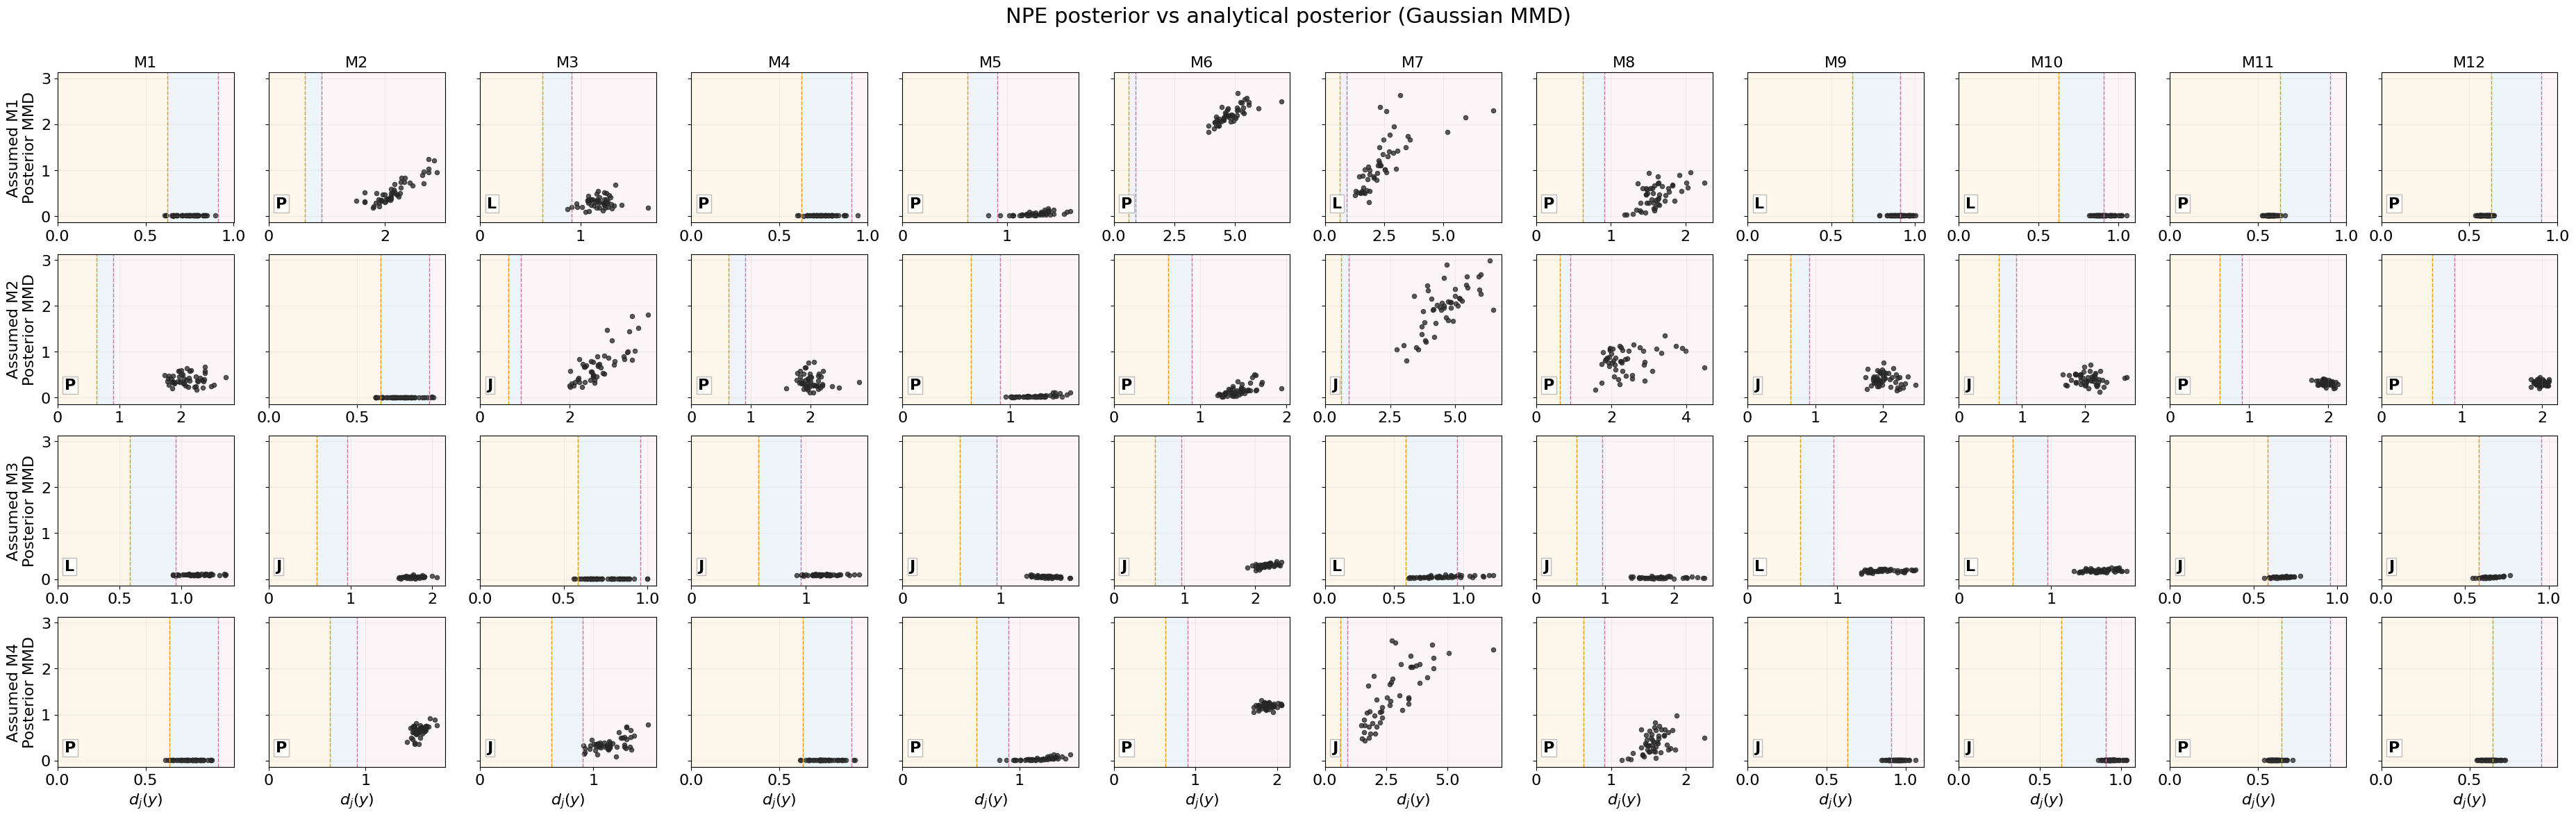

In [12]:
# Posterior MMD
sd.plot_posterior_metric_grid(
    posterior_df, metric="mmd", output_dir=figure_dir, sharey=True
);


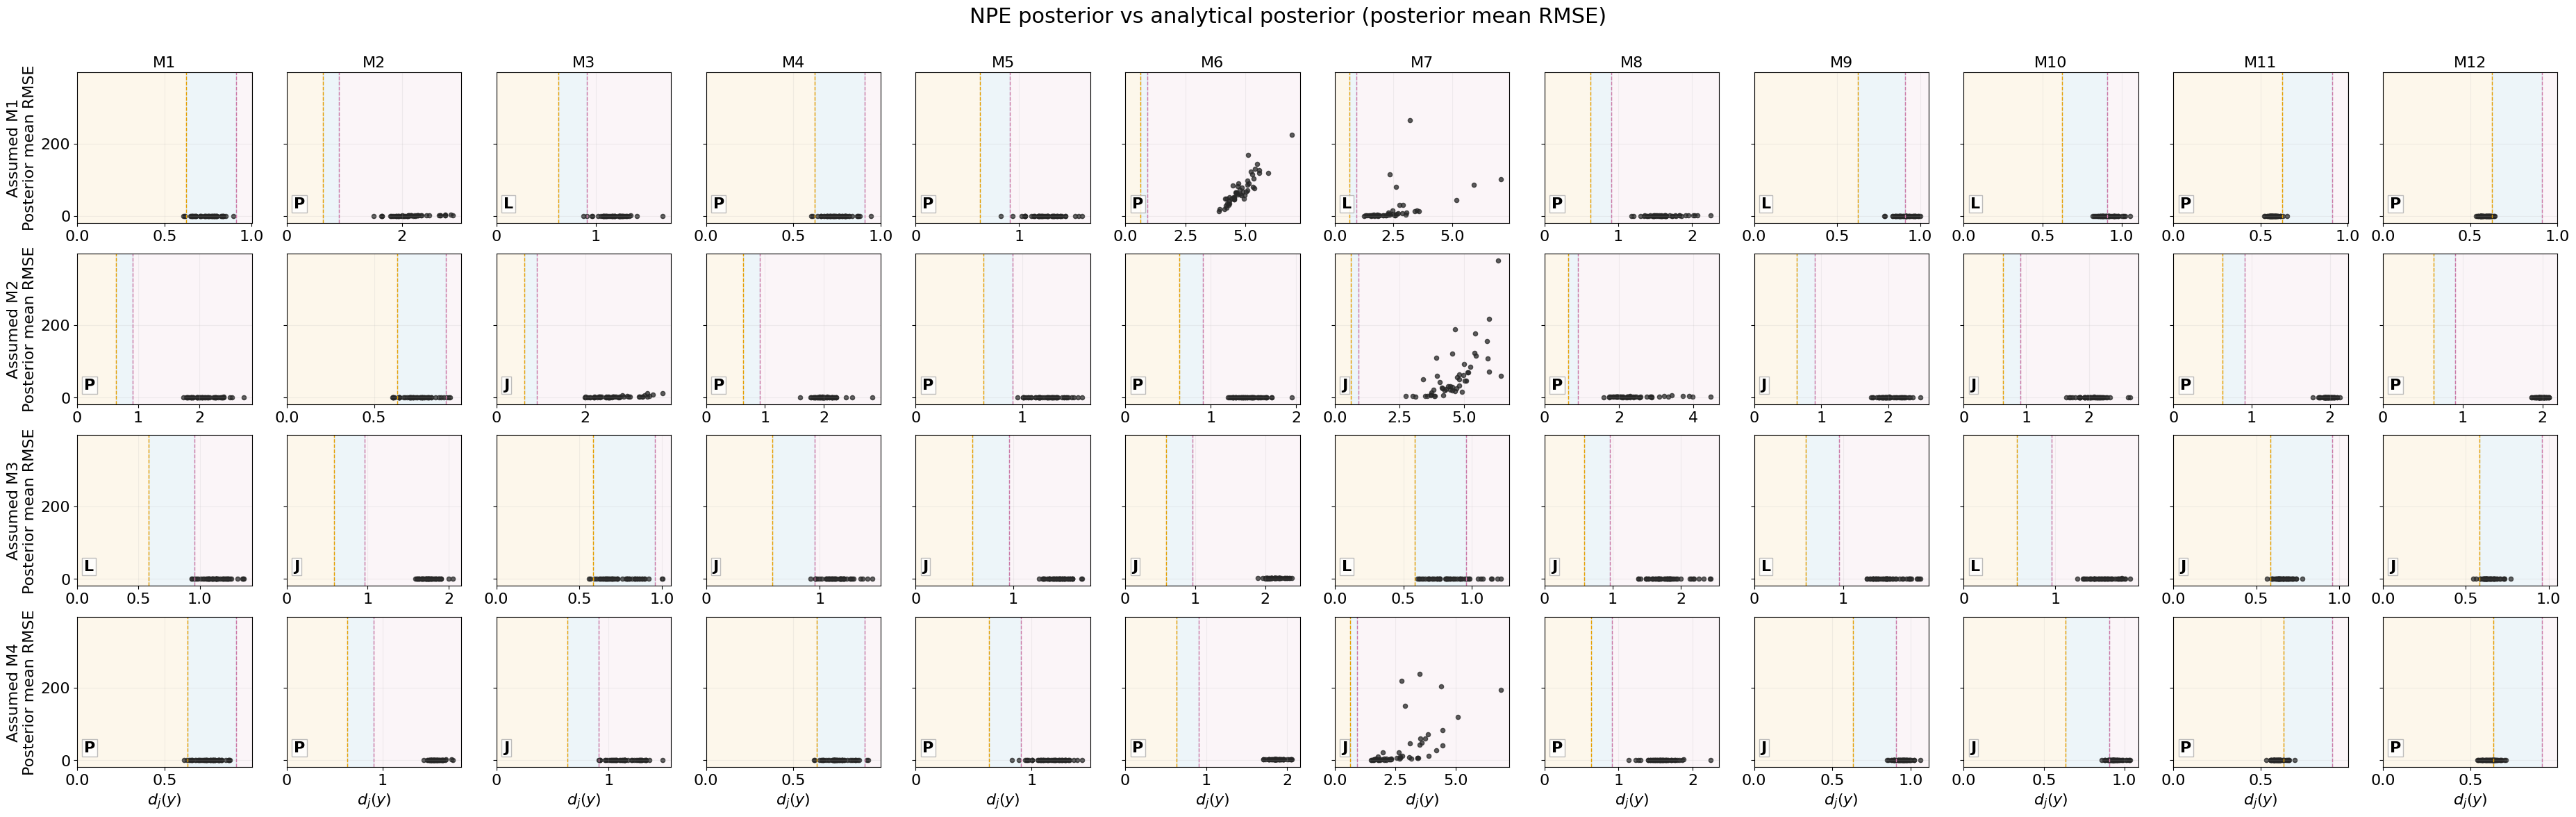

In [13]:
# Posterior RMSE
sd.plot_posterior_metric_grid(
    posterior_df, metric="mean_rmse", output_dir=figure_dir, sharey=True
);


## Plots

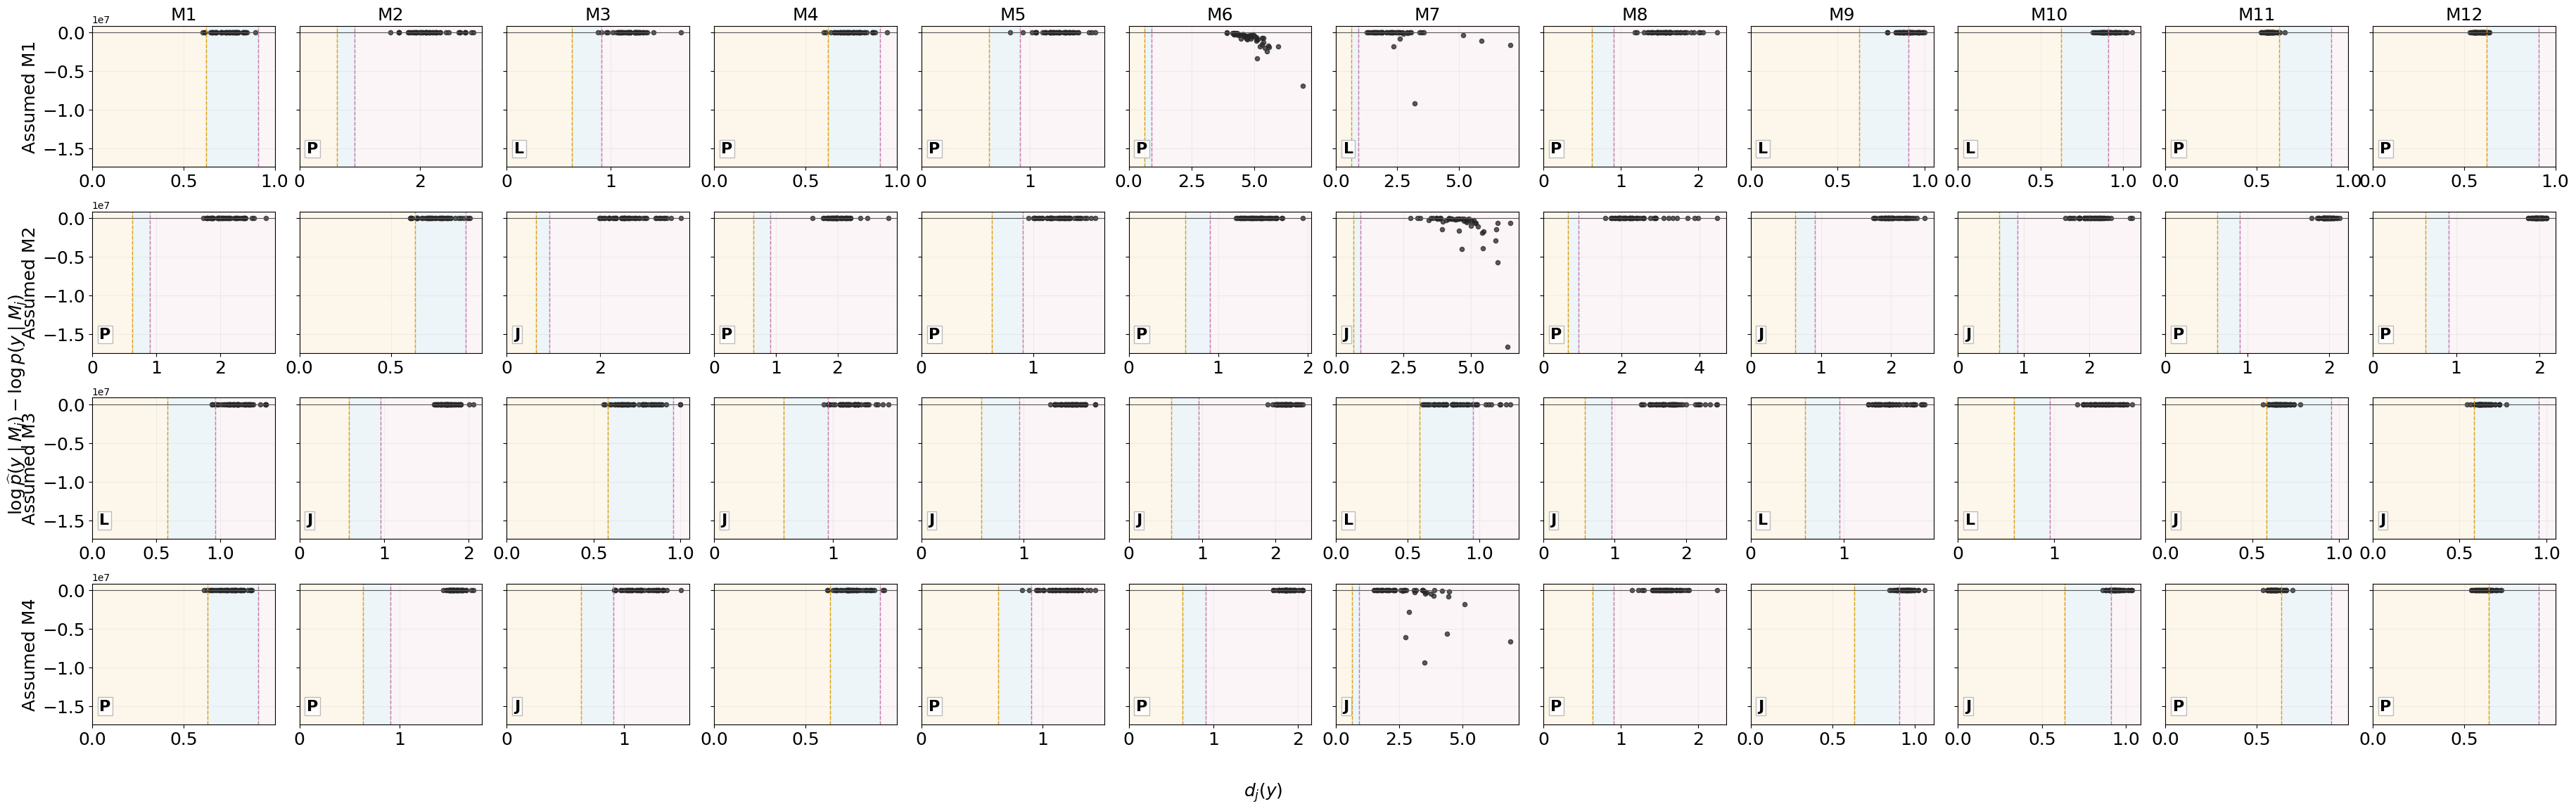

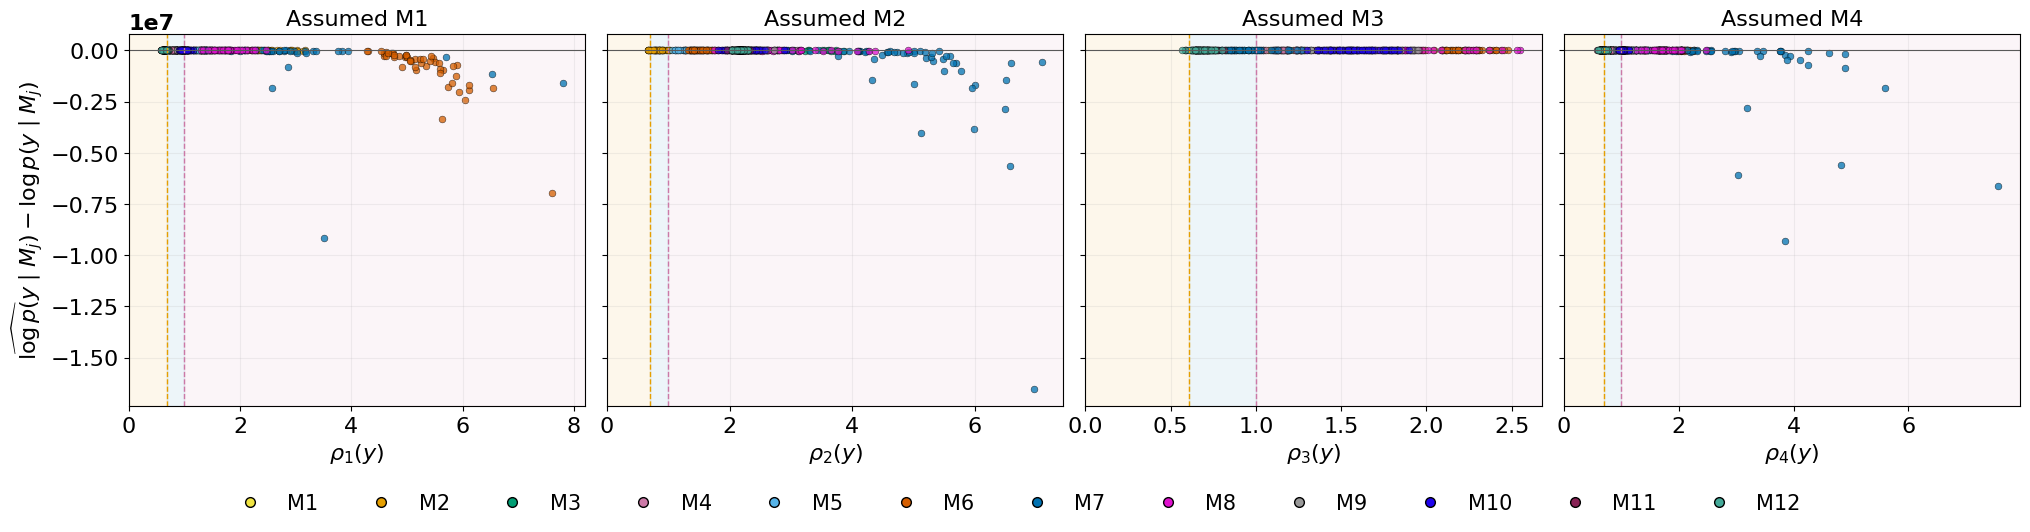

In [14]:
# signed logml error with shared y-axis
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir);
sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

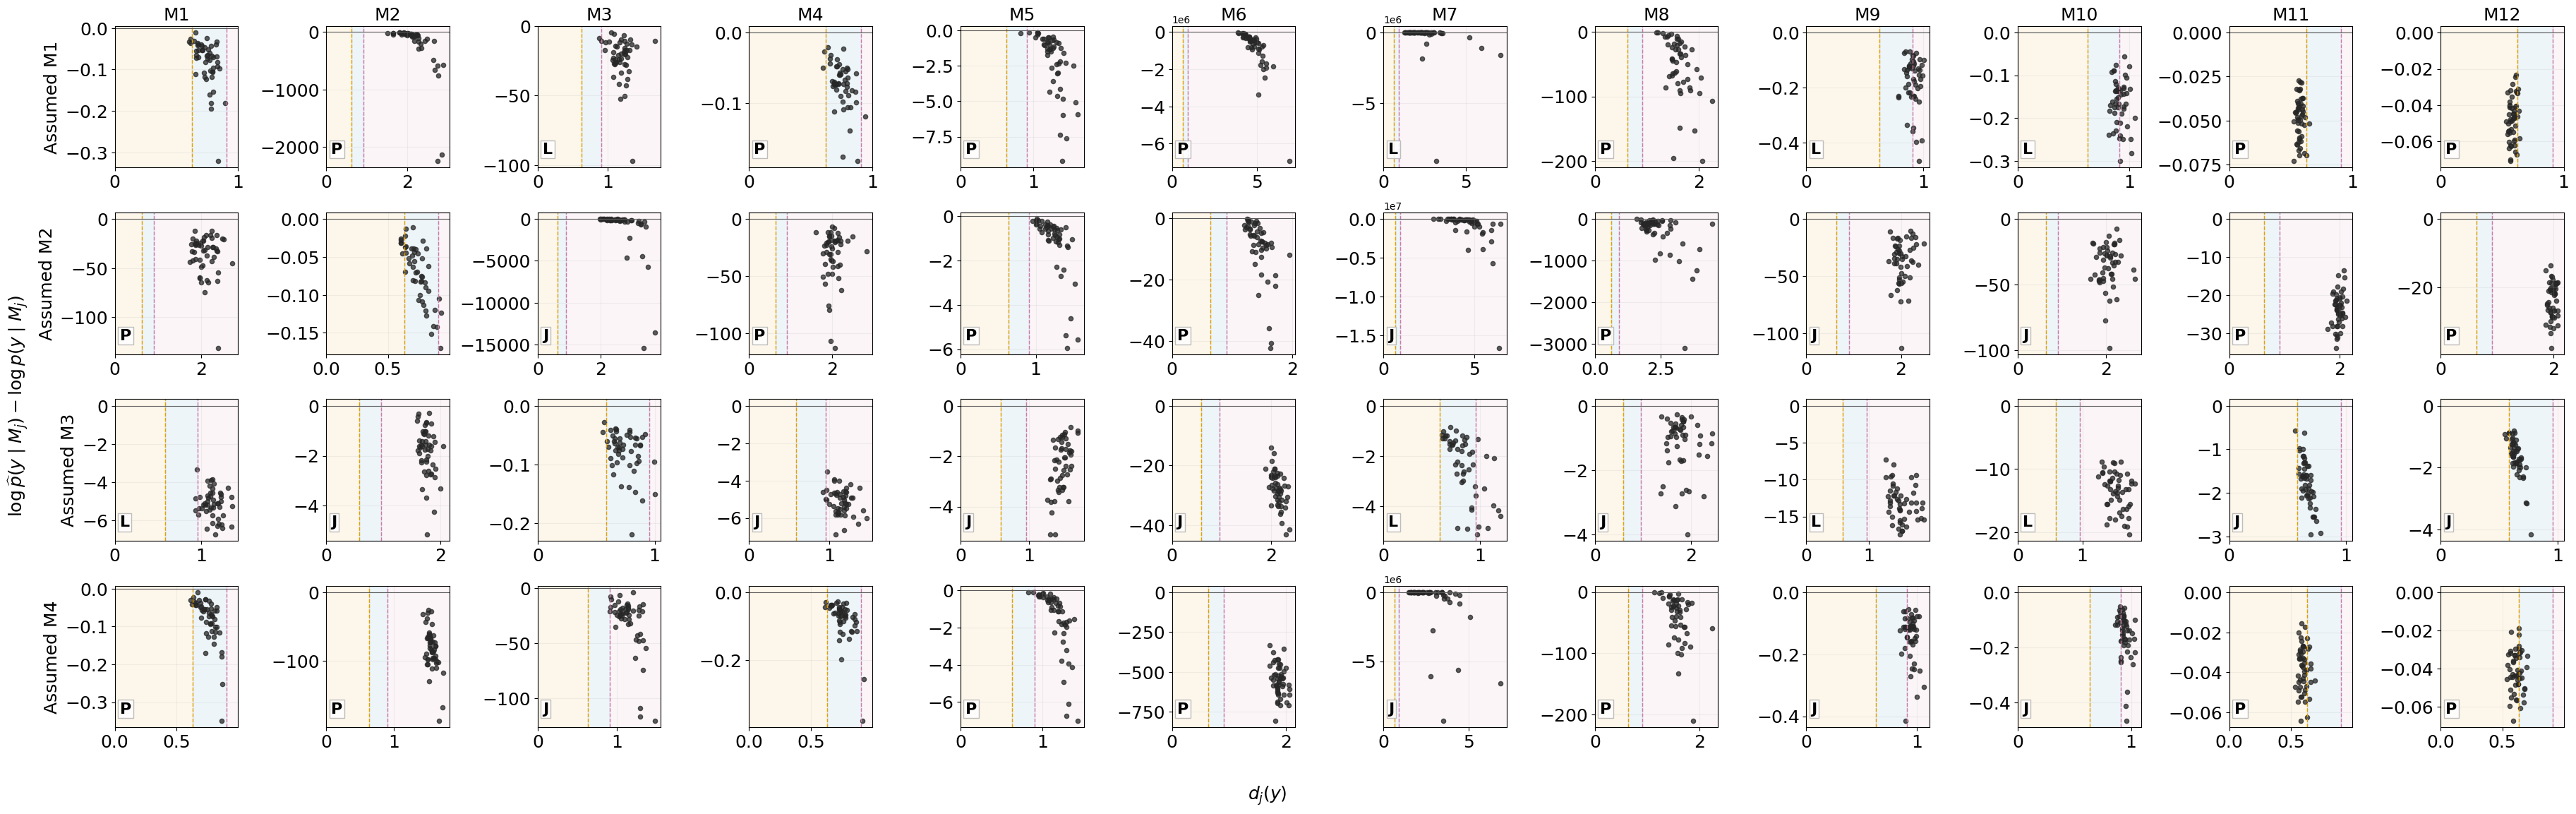

In [15]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir,sharey=False);

(<Figure size 1960x600 with 4 Axes>,
 array([<Axes: title={'center': '$p(M_1\\mid y)$'}, xlabel='$\\log(1+A(y))$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': '$p(M_2\\mid y)$'}, xlabel='$\\log(1+A(y))$'>,
        <Axes: title={'center': '$p(M_3\\mid y)$'}, xlabel='$\\log(1+A(y))$'>,
        <Axes: title={'center': '$p(M_4\\mid y)$'}, xlabel='$\\log(1+A(y))$'>],
       dtype=object))

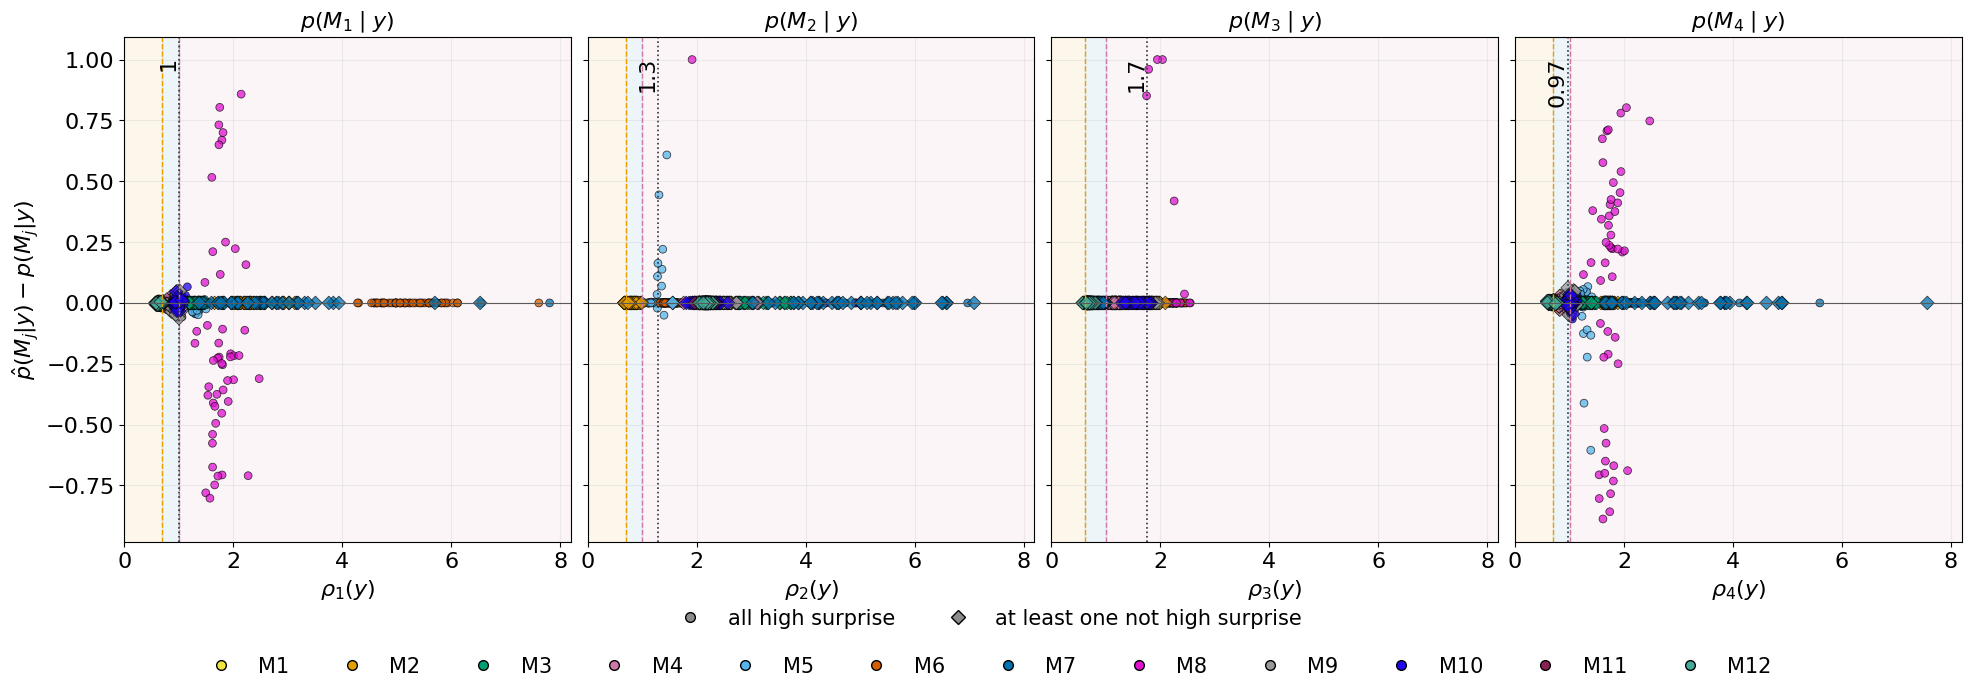

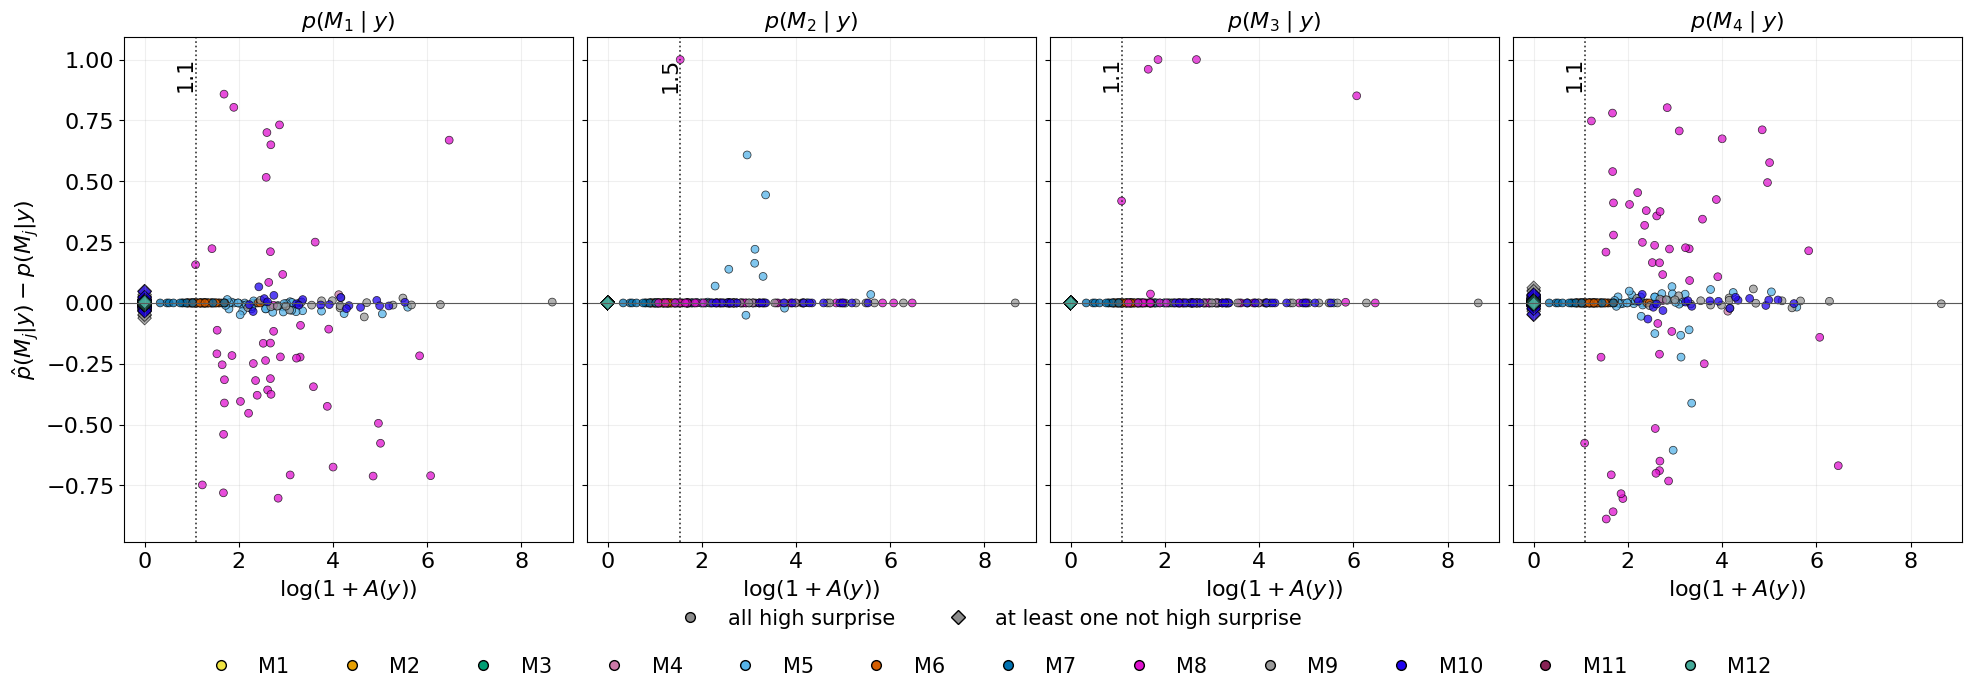

In [16]:
# PMP plots
sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",
                       sharex=True,x_min=0.0,error_bound=0.05,)
sd.plot_pmp_diagnostic(pmp_df,x="logA",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",
                       sharex=True, regions="ambiguity",error_bound=0.05,error_subset="all_extrapolative")



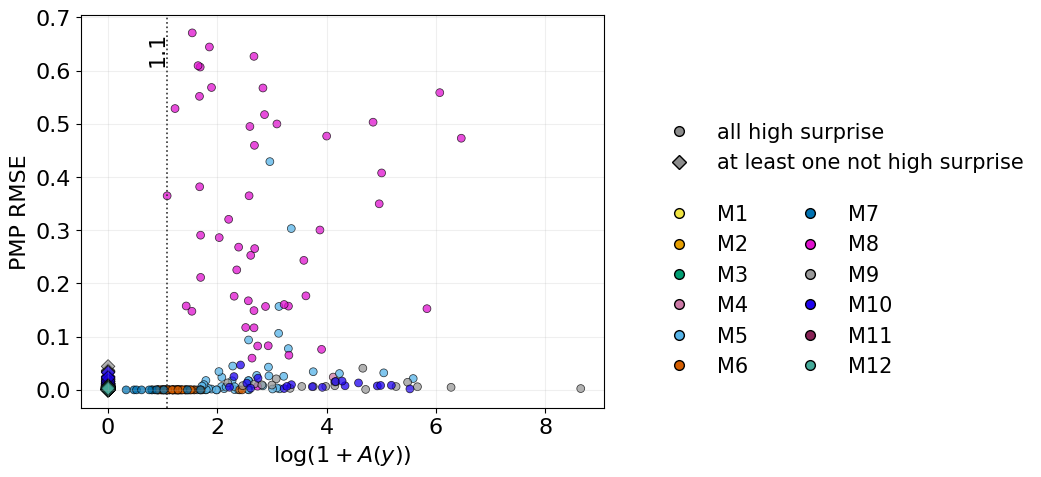

In [17]:
fig, ax = sd.plot_pmp_diagnostic(
    pmp_df,
    x="logA",
    y="rmse",
    group_by="global_extrapolation_source",
    estimate="npe",
    output_dir=None,
    sharex=True,
    x_min=-0.5,
    error_bound=0.05,
)

In [18]:
# # PMP estimates (NPE and NPMP) vs distance for each source model
# for source in sd.SOURCE_MODELS:
#     sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

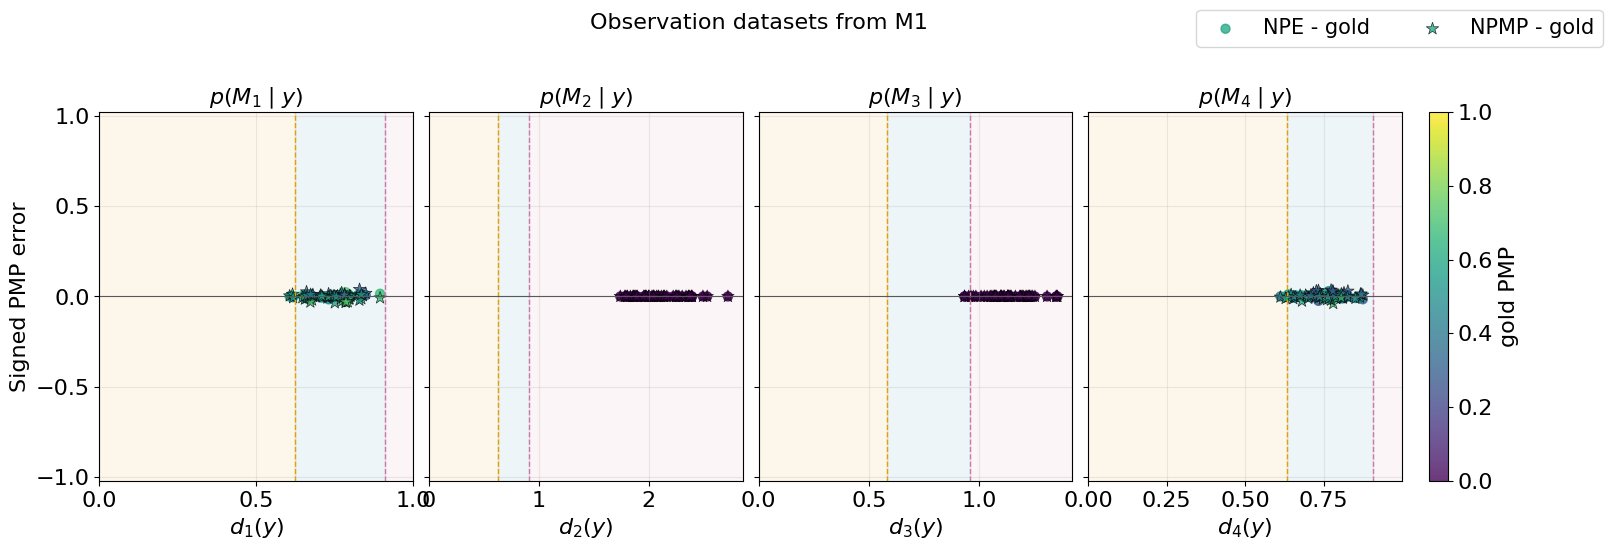

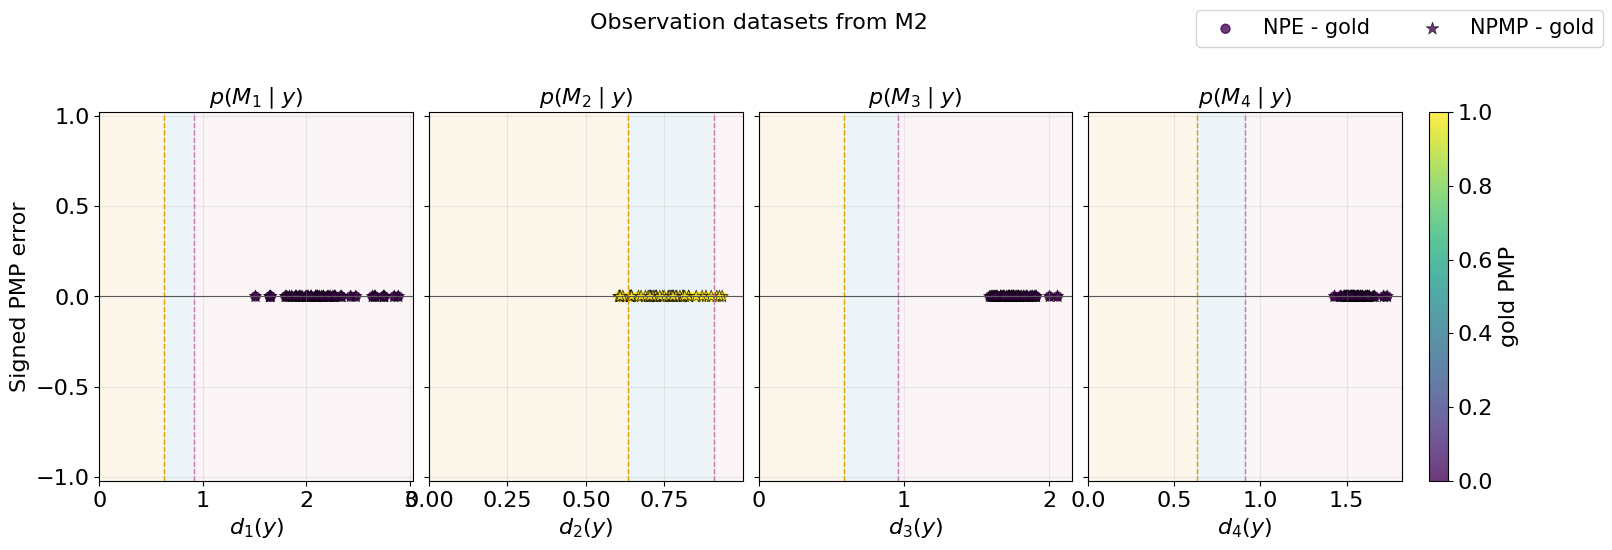

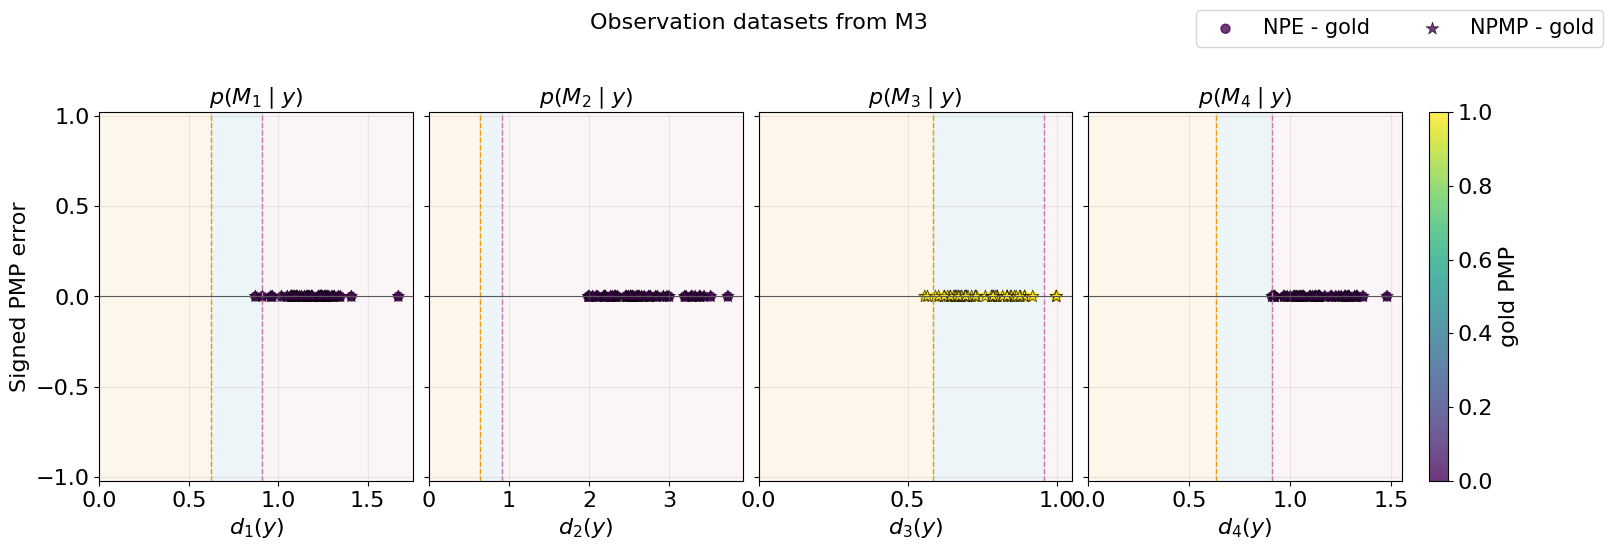

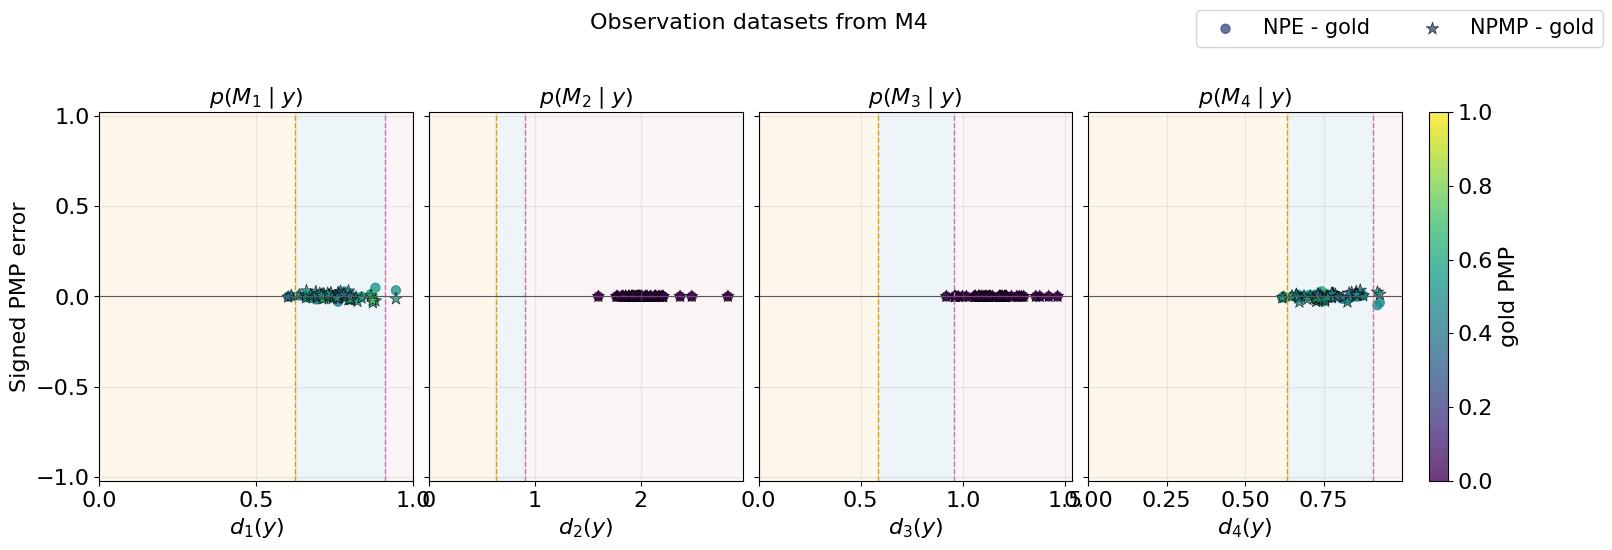

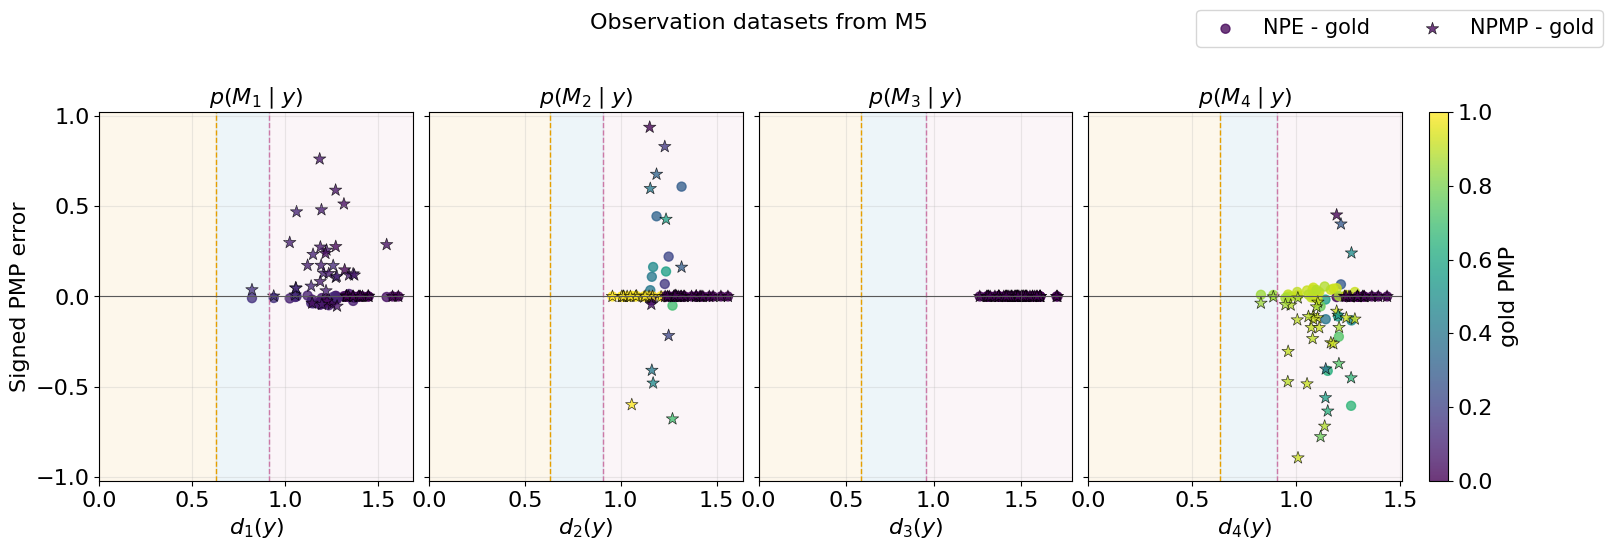

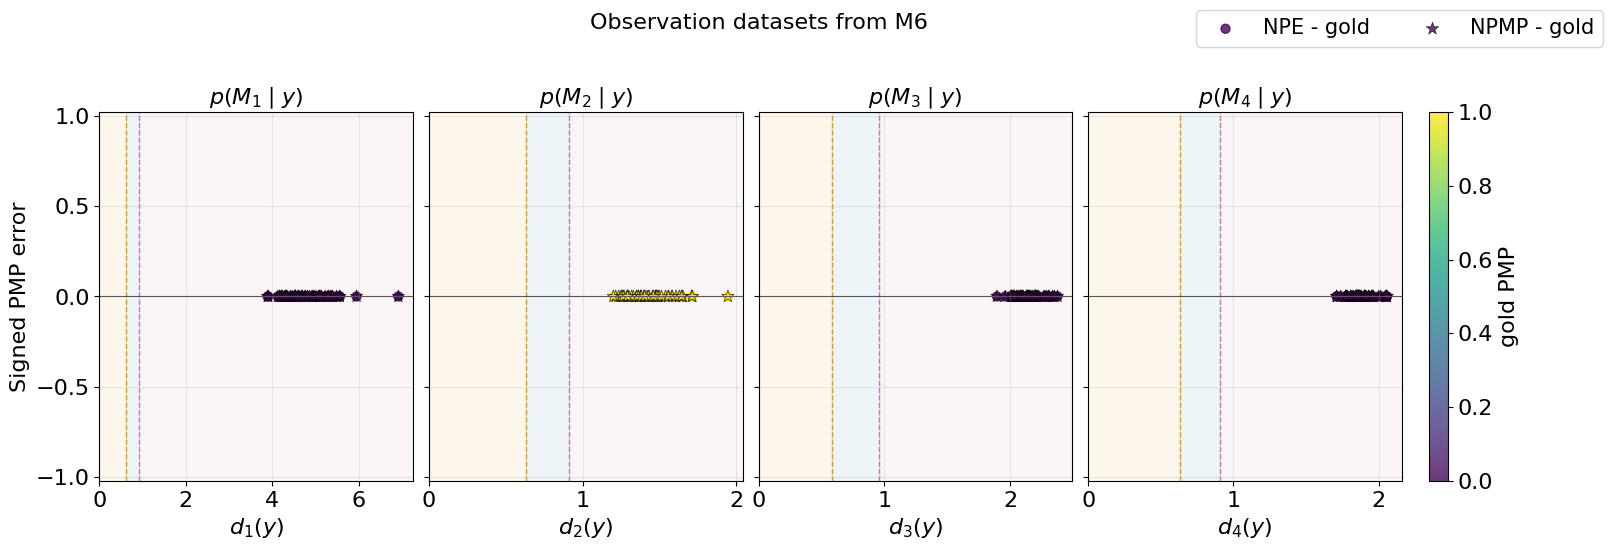

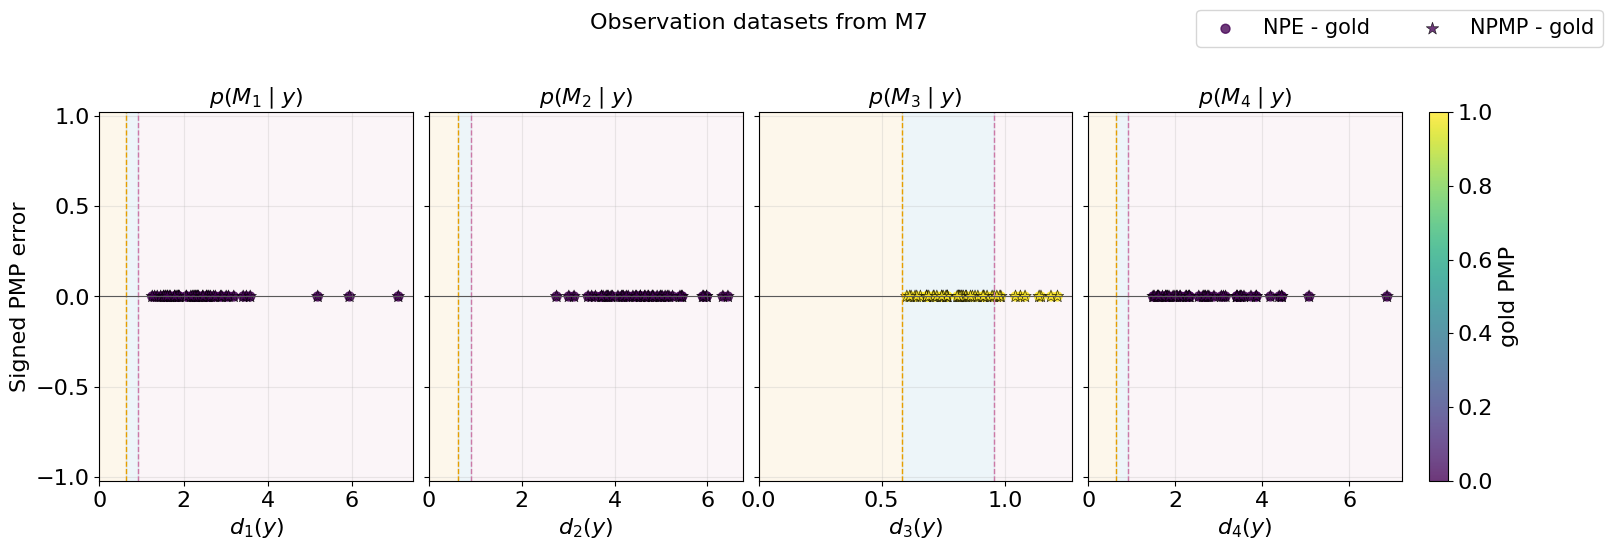

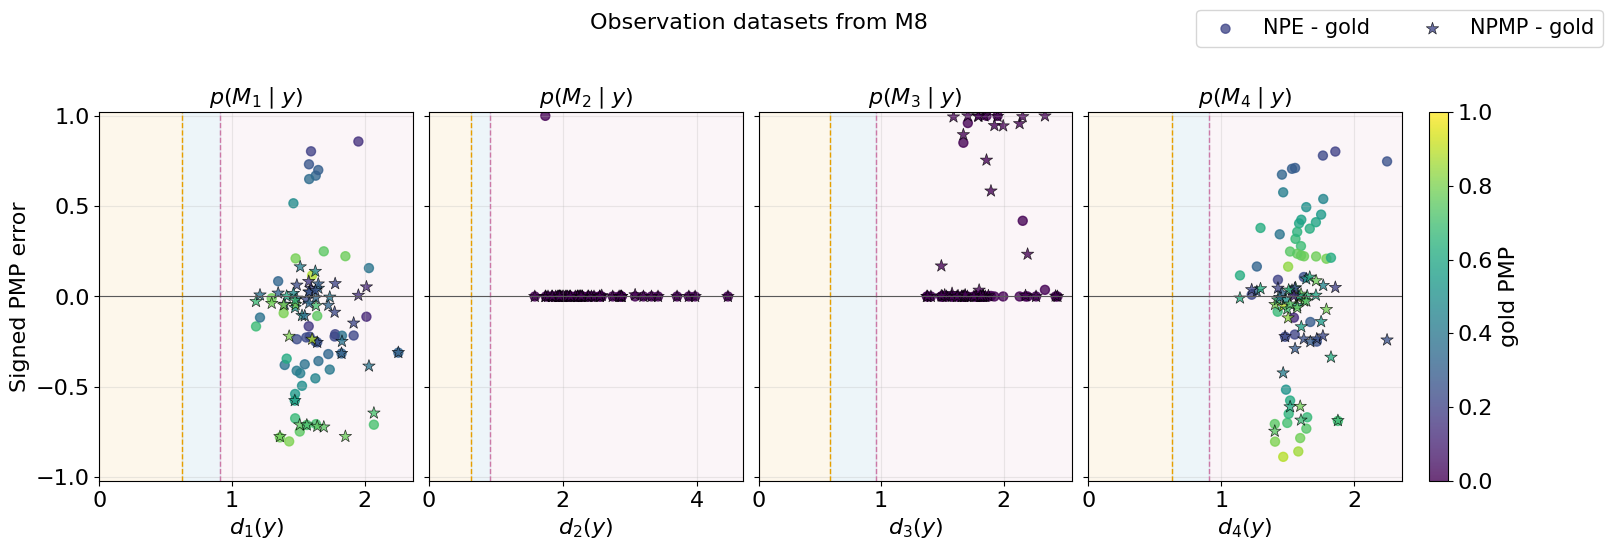

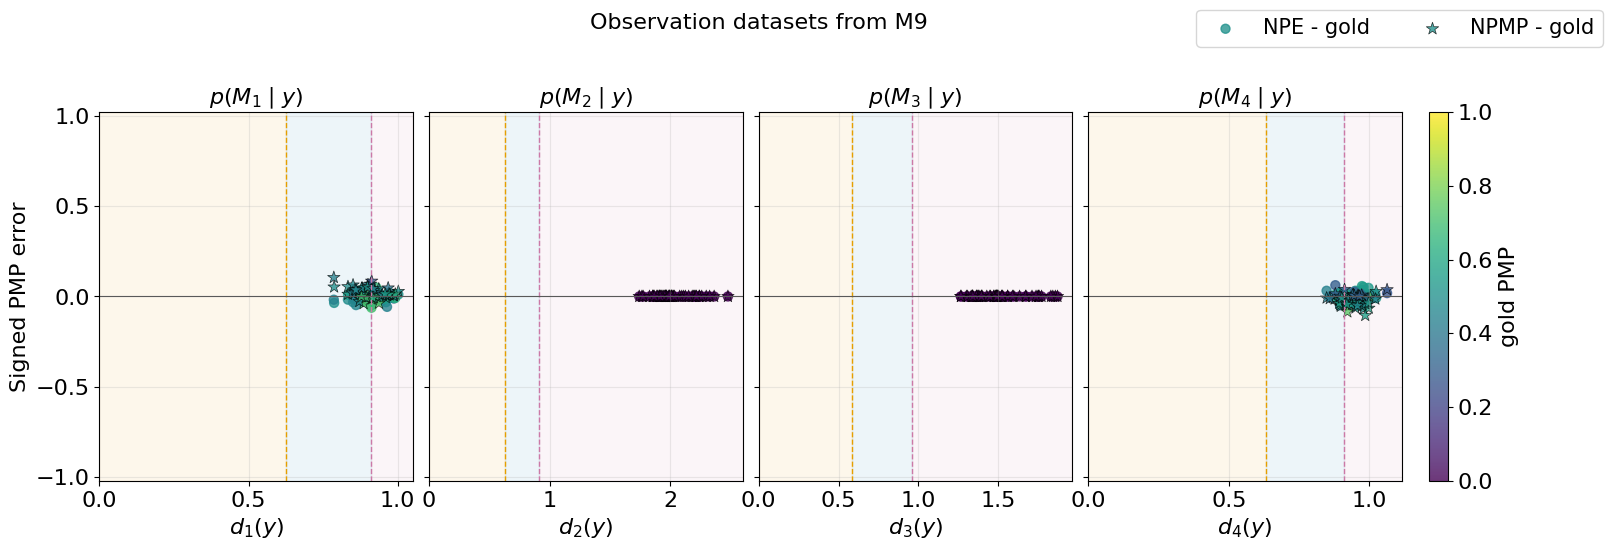

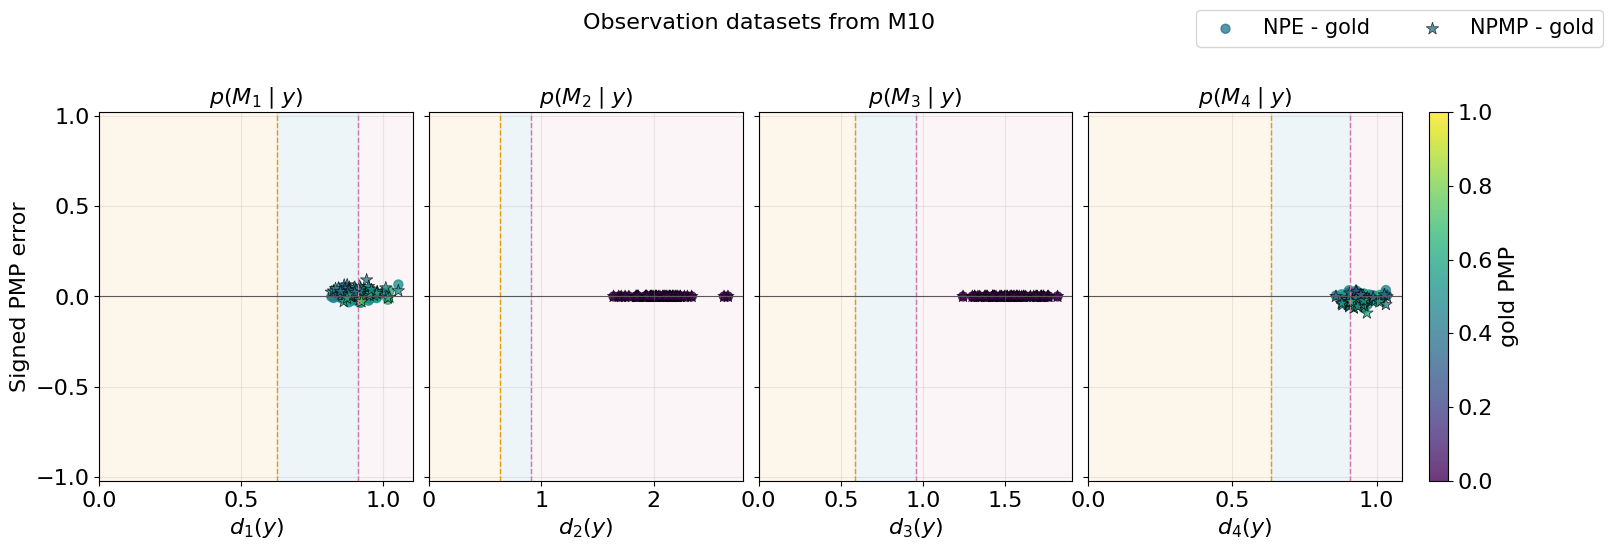

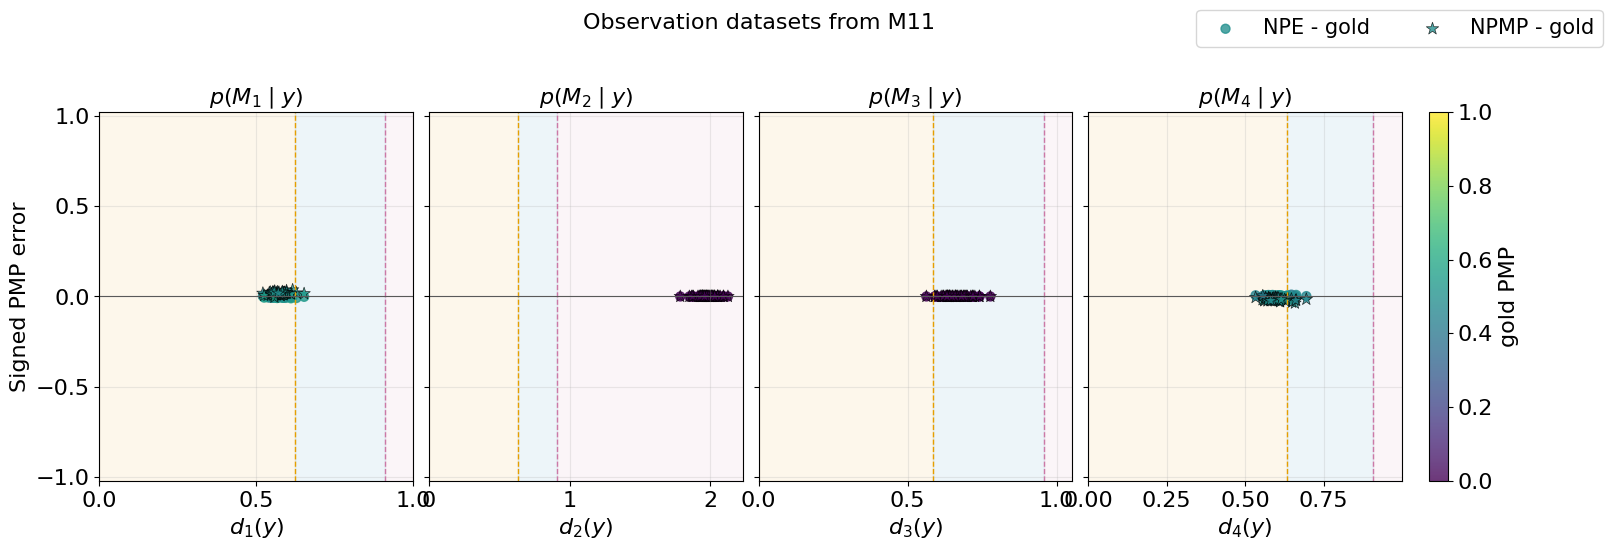

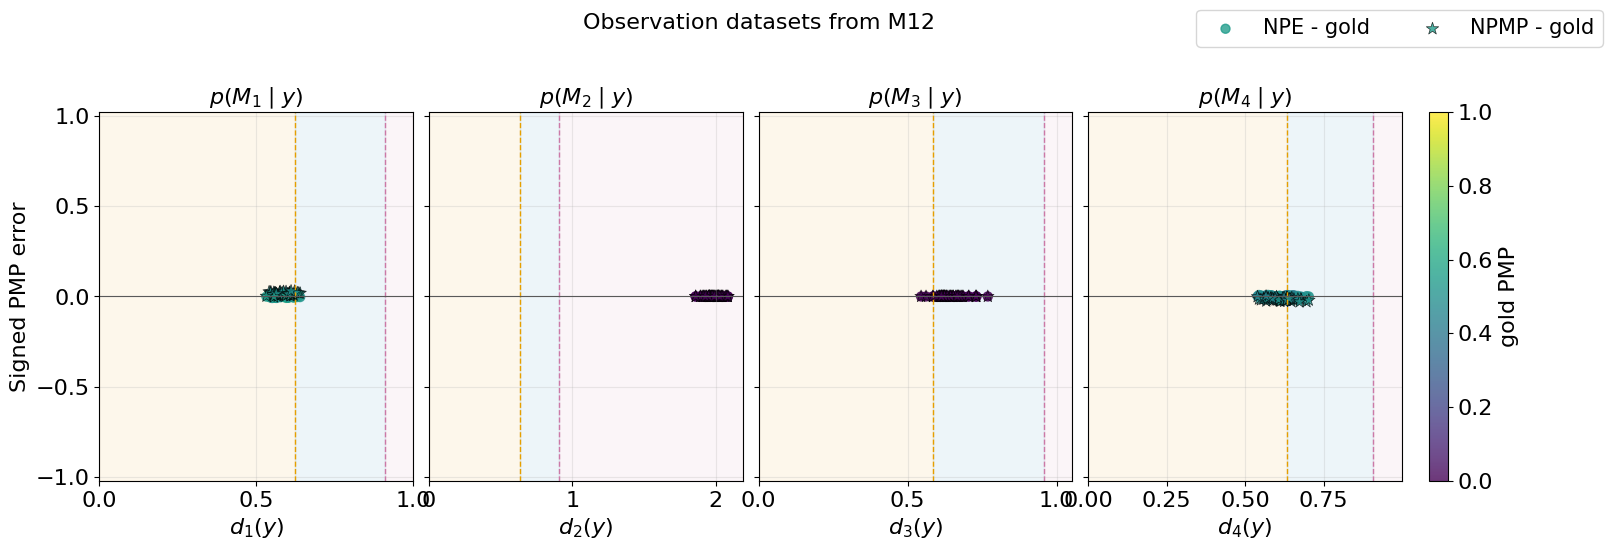

In [19]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)